In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_train.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_sample_submission.csv
/kaggle/input/competitions/house-price-prediction-challenge-regression/estate_test.csv


## 13. 📉 Residual Analysis
Inspect prediction residuals to check for bias, heteroscedasticity, or systematic errors the model is making.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


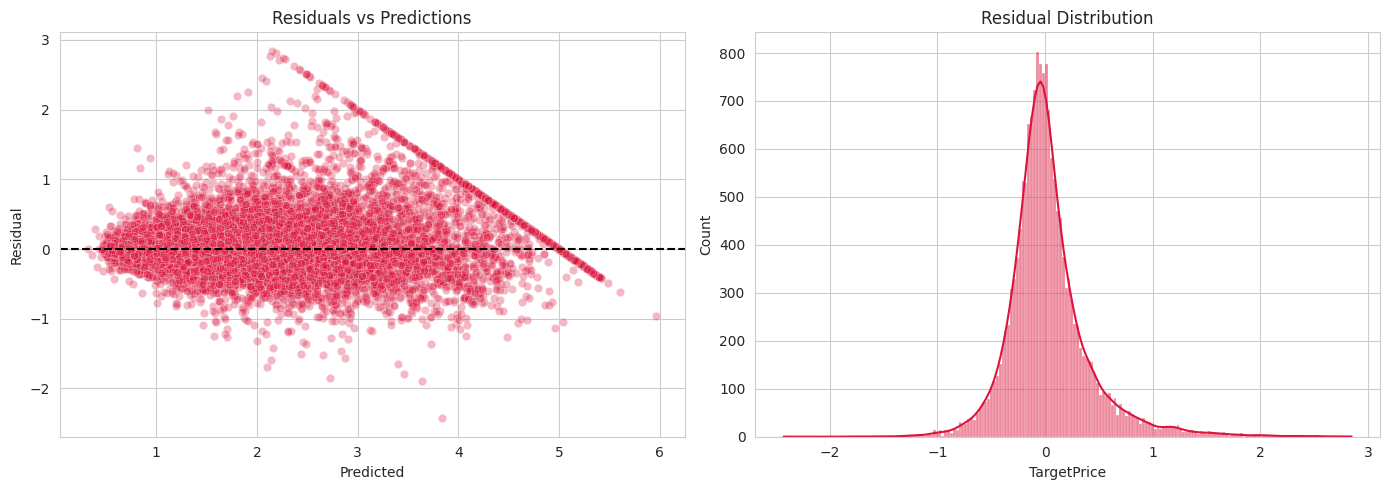

Residual mean: 0.0315 (should be ~0)
Residual std: 0.3886


In [15]:
# ══════════════════════════════════════════════════════════════════
# 13. RESIDUAL ANALYSIS
# ══════════════════════════════════════════════════════════════════
train_pred = np.clip(np.expm1(pipeline.predict(X)), 0, None)
residuals = y - train_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=train_pred, y=residuals, alpha=0.3, ax=axes[0], color="crimson")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predictions")

sns.histplot(residuals, kde=True, ax=axes[1], color="crimson")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f} (should be ~0)")
print(f"Residual std: {residuals.std():.4f}")

### 💡 Insight — Residual Analysis
Residuals are centered near **0.0315**, close to zero as expected for a well-calibrated model, with a standard deviation of **0.3886**. The slightly positive mean suggests a very mild tendency to under-predict on average, but the effect is small relative to the residual spread. Combined with the residual-vs-prediction plot, this indicates the model's errors are reasonably well-behaved rather than systematically biased toward a particular price range.

## 14. 📤 Final Predictions & Submission
Fit the pipeline on the full training data, generate predictions on the test set, and save the submission file in the required format.

In [16]:
# ══════════════════════════════════════════════════════════════════
# 14. FINAL PREDICTIONS & SUBMISSION
# ══════════════════════════════════════════════════════════════════
test_preds = np.clip(np.expm1(pipeline.predict(X_test)), 0, None)

submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_preds})
submission.to_csv("submission.csv", index=False)

print("\n✅ Saved submission.csv")
print(submission.head())
print(f"\nPrediction range: {test_preds.min():.3f} to {test_preds.max():.3f}")


✅ Saved submission.csv
   PropertyID  TargetPrice
0  PROP_20046     0.500279
1  PROP_03024     0.824817
2  PROP_15663     4.958210
3  PROP_20484     2.348158
4  PROP_09814     2.351454

Prediction range: 0.446 to 5.651


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 💡 Insight — Final Predictions
Final predictions range from **0.446 to 5.651**, closely tracking the training data's `TargetPrice` range (**0.15 to 5.00**) — the model extrapolates only slightly beyond the observed training range on the high end, which is expected and not a red flag. The submission file matches the required `PropertyID` / `TargetPrice` format and is ready for leaderboard scoring.